In [32]:
import hereutil
hereutil.add_to_sys_path(hereutil.here())
from src.common_basis_gizmosql import *

In [33]:
df = p(
    f('all_individual_actors')
    .filter(c('source') == 'vd17')
    .group_by(c('value'))
    .agg(c('record_number').n_unique())
).to_pandas()

df

,value,record_number
0,9$004990994|V$Tpv2|7$gnd/128436891|w$piz|A$Sch...,11
1,9$004697480|V$Tpv1|7$gnd/124536743|w$piz|A$Pel...,18
2,9$005173701|V$Tpv1|7$gnd/123412862|w$piz|A$Pfl...,3
3,9$00441537x|V$Tpv1|7$gnd/121059626|w$piz|A$Mau...,1
4,9$004059077|V$Tpv1|7$gnd/124426581|w$piz|A$Ben...,23
...,...,...
514630,d$Jonas|a$Nordhamerus|B$BeiträgerIn|4$ctb,1
514631,d$Valentinus|a$Velthm|B$BeiträgerIn|4$ctb,1
514632,C$3000|d$Martin|a$Firmian,1
514633,C$3010|d$Susanne Barbara|a$Böthicher,1


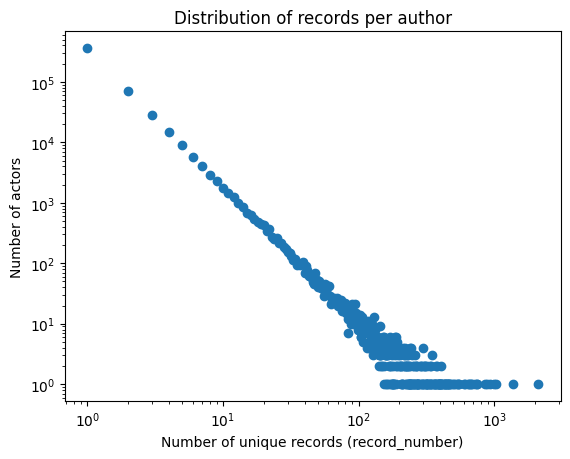

In [34]:
import matplotlib.pyplot as plt

# Count how many actors have each specific record_count
counts = df['record_number'].value_counts().sort_index()

# Plot the distribution
counts.plot(kind='line', marker='o', linestyle='')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of unique records (record_number)')
plt.ylabel('Number of actors')
plt.title('Distribution of records per author')
plt.show()

# Single author network extraction

In [35]:
target_value = '9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Stainmayr|D$Michael|M$1701'
matched_row = df[df['value'] == target_value]

matched_row

,value,record_number
246360,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,19


In [36]:
target_value = '9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Stainmayr|D$Michael|M$1701'

df_single_author = p(
    f('all_individual_actors')
    .filter(c('value') == target_value)
    .filter(c('source') == 'vd17')
    .join(f('all_publishers'), on=['record_number', 'source'], how='inner')
).to_pandas()

df_single_author

,record_number,field_number,field_code,value,source,publisher
0,162123,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
1,162123,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
2,162124,14,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
3,162124,14,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
4,168339,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
5,168339,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
6,168340,15,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
7,168340,15,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
8,173292,18,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Wagner
9,173292,18,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Geldern


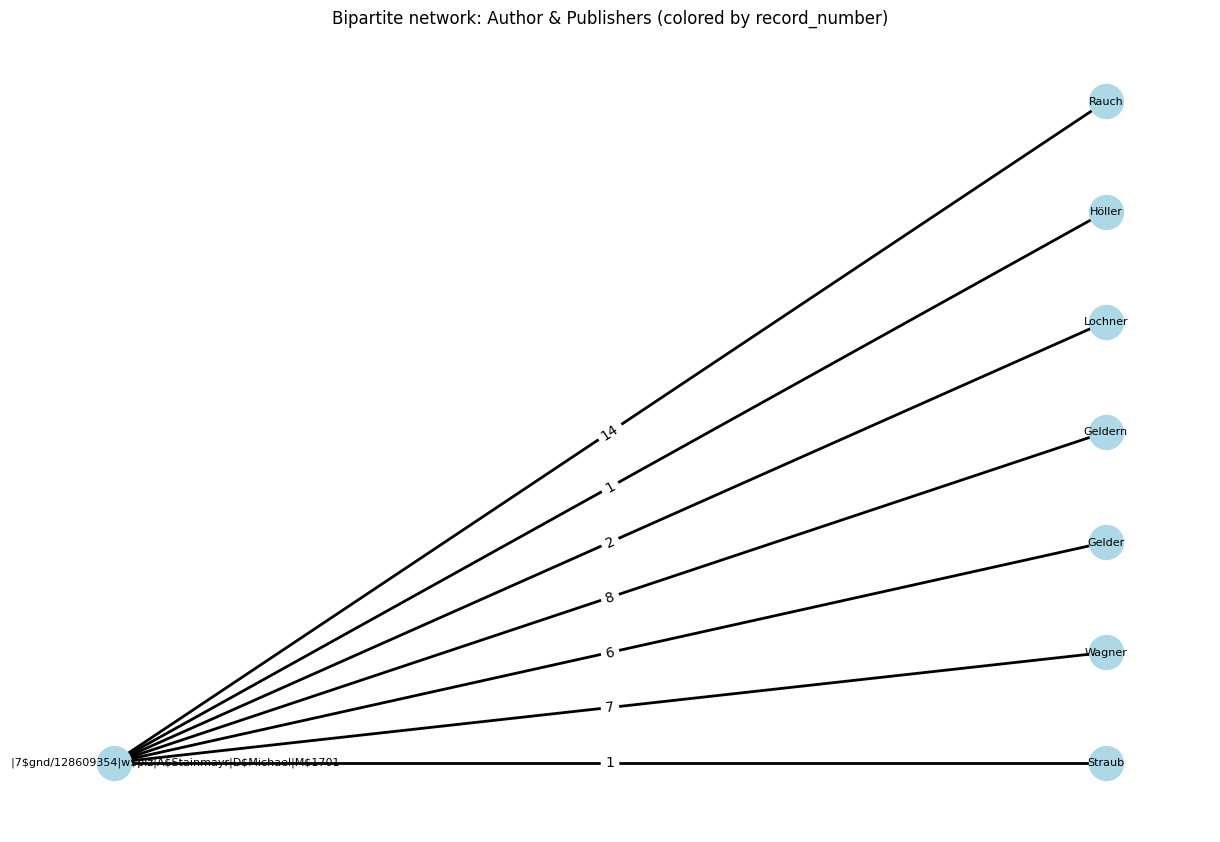

In [37]:
# import graph_tool
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add nodes with the bipartite attribute
authors = df_single_author['value'].unique()
publishers = df_single_author['publisher'].unique()

G.add_nodes_from(authors, bipartite=0)
G.add_nodes_from(publishers, bipartite=1)

# Add edges and calculate weights
for _, row in df_single_author.iterrows():
    u = row['value']
    v = row['publisher']
    if G.has_edge(u, v):
        G.edges[u, v]['weight'] += 1
    else:
        G.add_edge(u, v, weight=1, record_number=row['record_number'])

pos = nx.bipartite_layout(G, authors)

# Visual improvement: extract weights to adjust edge widths dynamically
weights = [G.edges[u, v]['weight'] * 2 for u, v in G.edges()]

# Plot network
plt.figure(figsize=(12, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    node_size=600,
    font_size=8,
    width=2
)
# Add edge labels to show the text weight
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)


plt.title('Bipartite network: Author & Publishers (colored by record_number)')
plt.show()

/var/folders/nl/k4hzs1551xv8ll54zbf4g8000000gn/T/ipykernel_16553/589383707.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', max(len(books), 1))


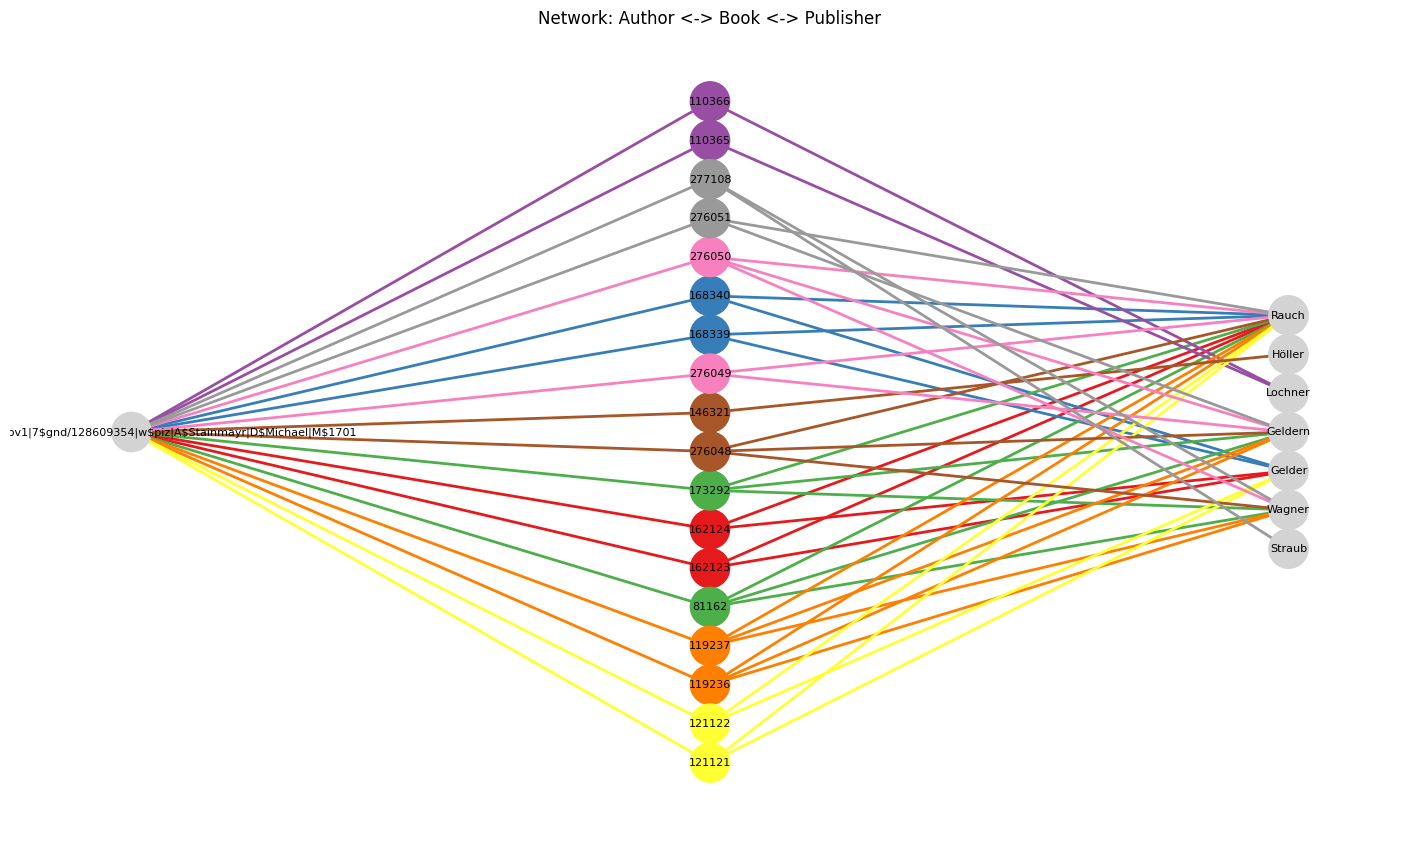

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Get unique entities
authors = df_single_author['value'].unique()
books = df_single_author['record_number'].unique()
publishers = list(set(df_single_author['publisher'].unique()) - set(books)) # Ensure no overlap in node names

# Add nodes with 'layer' attribute for multipartite layout
for node in authors:
    G.add_node(node, layer=0, node_type='author')
for node in books:
    G.add_node(node, layer=1, node_type='book')
for node in publishers:
    G.add_node(node, layer=2, node_type='publisher')

# Define a color map for unique books (record numbers)
cmap = plt.cm.get_cmap('Set1', max(len(books), 1))
book_colors = {book: cmap(i) for i, book in enumerate(books)}

# Add edges connecting Author <-> Book and Book <-> Publisher
for _, row in df_single_author.iterrows():
    author = row['value']
    book = row['record_number']
    publisher = row['publisher']
    
    # Store the associated book in the edge for coloring
    G.add_edge(author, book, book_id=book)
    G.add_edge(book, publisher, book_id=book)

pos = nx.multipartite_layout(G, subset_key="layer")

# Assign colors to nodes (authors/publishers get grey, books get their specific color)
node_colors = []
for node, data in G.nodes(data=True):
    if data['node_type'] == 'book':
        node_colors.append(book_colors[node])
    else:
        node_colors.append('lightgray')

# Assign colors to edges based on the connected book
edge_colors = [book_colors[G.edges[u, v]['book_id']] for u, v in G.edges()]

# Plot network
plt.figure(figsize=(14, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=800,
    font_size=8,
    edge_color=edge_colors,
    width=2
)
plt.title('Network: Author <-> Book <-> Publisher')
plt.show()

In [39]:
unique_records = df_single_author['record_number'].unique().tolist()

df_all_actors = p(
    f('all_individual_actors')
    .filter(c('source') == 'vd17')
    .filter(c('record_number').is_in(unique_records))
    .join(
        f('all_publishers'), 
        left_on=['record_number', 'source'], 
        right_on=['record_number', 'source'], 
        how='left'
    )
    .join(
        f('all_corporate_actors'), 
        left_on=['record_number', 'source'], 
        right_on=['record_number', 'source'], 
        how='left'
    )
).to_pandas()

df_all_actors

,record_number,field_number,field_code,value,source,publisher,field_number_right,field_code_right,value_right
0,276048,19,028C,d$Michael|a$Colbert|B$Zensor,vd17,Rauch,24.0,029F,a$Gemeiner Hochlöbl. Landschafft in Bayrn Woll...
1,276048,19,028C,d$Michael|a$Colbert|B$Zensor,vd17,Geldern,24.0,029F,a$Gemeiner Hochlöbl. Landschafft in Bayrn Woll...
2,276048,19,028C,d$Michael|a$Colbert|B$Zensor,vd17,Wagner,24.0,029F,a$Gemeiner Hochlöbl. Landschafft in Bayrn Woll...
3,276048,20,028C,d$Ignat. Christoph.|a$Kerl|B$Zensor,vd17,Rauch,24.0,029F,a$Gemeiner Hochlöbl. Landschafft in Bayrn Woll...
4,276048,20,028C,d$Ignat. Christoph.|a$Kerl|B$Zensor,vd17,Geldern,24.0,029F,a$Gemeiner Hochlöbl. Landschafft in Bayrn Woll...
...,...,...,...,...,...,...,...,...,...
209,276051,25,028G,P$Patres & fratres Osterhovienses|B$Beiträger,vd17,Geldern,NaN,NaN,NaN
210,276051,25,028G,P$Patres & fratres Osterhovienses|B$Beiträger,vd17,Rauch,NaN,NaN,NaN
211,146321,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Höller,NaN,NaN,NaN
212,146321,19,028C,d$Adamus|a$Cammerpaur|B$ZensorIn|4$cns,vd17,Höller,NaN,NaN,NaN


/var/folders/nl/k4hzs1551xv8ll54zbf4g8000000gn/T/ipykernel_16553/2836388473.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', max(len(books), 1))


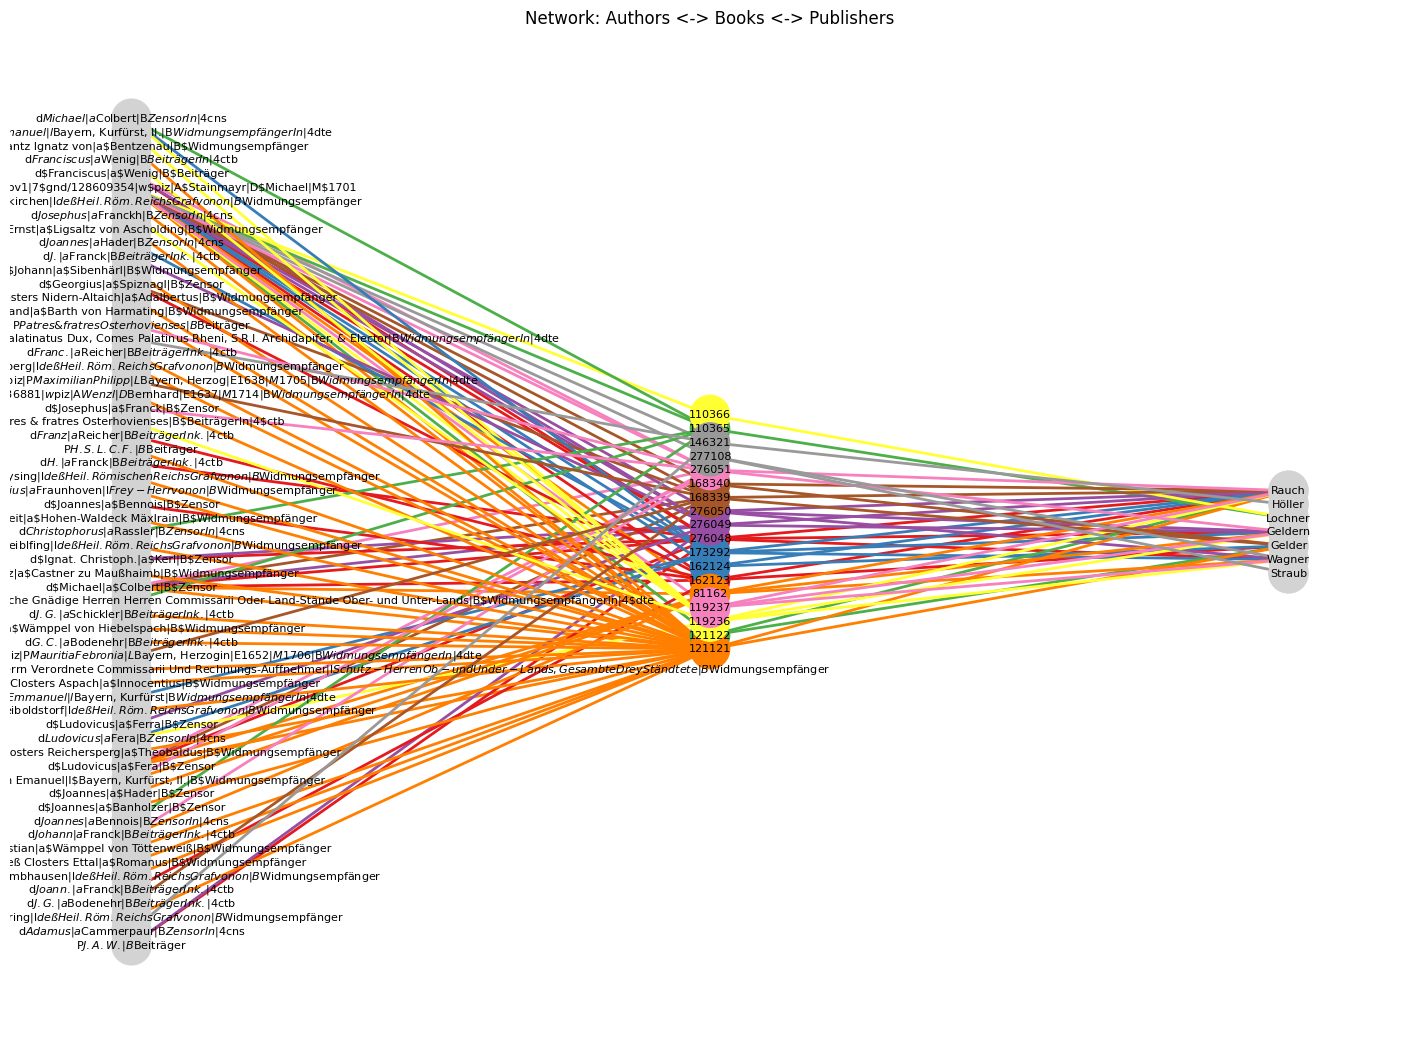

In [40]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

G = nx.Graph()

# Get unique entities, removing NaNs
authors = df_all_actors['value'].dropna().unique()
books = df_all_actors['record_number'].dropna().unique()
# Ensure no overlap in node names across categories
publishers = list(set(df_all_actors['publisher'].dropna().unique()) - set(books) - set(authors)) 

# Add nodes with 'layer' attribute for multipartite layout
for node in authors:
    G.add_node(node, layer=0, node_type='author')
for node in books:
    G.add_node(node, layer=1, node_type='book')
for node in publishers:
    G.add_node(node, layer=2, node_type='publisher')

# Define a color map for unique books (record numbers)
cmap = plt.cm.get_cmap('Set1', max(len(books), 1))
book_colors = {book: cmap(i) for i, book in enumerate(books)}

# Add edges connecting Author <-> Book and Book <-> Publisher
for _, row in df_all_actors.iterrows():
    author = row['value']
    book = row['record_number']
    publisher = row['publisher']
    
    # Store the associated book in the edge for coloring
    if pd.notnull(author) and pd.notnull(book):
        G.add_edge(author, book, book_id=book)
        
    if pd.notnull(book) and pd.notnull(publisher) and publisher in publishers:
        G.add_edge(book, publisher, book_id=book)

pos = nx.multipartite_layout(G, subset_key="layer")

# Assign colors to nodes (authors/publishers get grey, books get their specific color)
node_colors = []
for node, data in G.nodes(data=True):
    if data['node_type'] == 'book':
        node_colors.append(book_colors.get(node, 'lightgray'))
    else:
        node_colors.append('lightgray')

# Assign colors to edges based on the connected book
edge_colors = [book_colors[G.edges[u, v]['book_id']] for u, v in G.edges()]

# Plot network
plt.figure(figsize=(14, 10))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=800,
    font_size=8,
    edge_color=edge_colors,
    width=2
)
plt.title('Network: Authors <-> Books <-> Publishers')
plt.show()

## Strict publishers relationships

In [41]:
df_single_author_publishers_rel = df_single_author[df_single_author.duplicated('record_number', keep=False)]

pub_counts = df_single_author_publishers_rel.groupby('record_number').size()
exact_links = (pub_counts * (pub_counts - 1) / 2).sum()

print(f"Dropped rows: {df_single_author.shape[0] - df_single_author_publishers_rel.shape[0]}")
print(f"Expected sum of edge weights: {int(exact_links)}")

df_single_author_publishers_rel

Dropped rows: 3
Expected sum of edge weights: 27


,record_number,field_number,field_code,value,source,publisher
0,162123,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
1,162123,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
2,162124,14,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
3,162124,14,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
4,168339,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
5,168339,17,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
6,168340,15,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Gelder
7,168340,15,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Rauch
8,173292,18,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Wagner
9,173292,18,028A,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,vd17,Geldern


In [42]:
# Publisher relationships: filter based on the shared books nodes (strict: weight on the number of edges)

target_value = '9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Stainmayr|D$Michael|M$1701'

df_publisher_edges = p(
    f('all_individual_actors')
    .filter(c('value') == target_value)
    .filter(c('source') == 'vd17')
    .join(f('all_publishers').rename({'publisher': 'publisher_1'}), on=['record_number', 'source'], how='inner')
    .join(f('all_publishers').rename({'publisher': 'publisher_2'}), on=['record_number', 'source'], how='inner')
    .filter(c('publisher_1') < c('publisher_2'))
    .group_by('publisher_1', 'publisher_2')
    .agg(c('record_number').n_unique().alias('weight'))
).to_pandas()

df_publisher_edges


,publisher_1,publisher_2,weight
0,Gelder,Rauch,6
1,Rauch,Wagner,6
2,Geldern,Wagner,6
3,Straub,Wagner,1
4,Geldern,Rauch,8


## Loose publishers relationships

In [43]:
n = df_single_author['publisher'].nunique()
print(f"Expected number of publisher edges: {n * (n - 1) // 2}")

df_single_author.groupby('publisher')['record_number'].nunique().reset_index(name='weight')

Expected number of publisher edges: 21


,publisher,weight
0,Gelder,6
1,Geldern,8
2,Höller,1
3,Lochner,2
4,Rauch,14
5,Straub,1
6,Wagner,7


In [44]:
target_value = '9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Stainmayr|D$Michael|M$1701'

# 1. Base query: compute author-publisher weights lazily
author_pubs = (
    f('all_individual_actors')
    .filter(c('value') == target_value)
    .filter(c('source') == 'vd17')
    .join(f('all_publishers'), on=['record_number', 'source'], how='inner')
    .group_by('value', 'publisher')
    .agg(c('record_number').n_unique().alias('weight'))
)

# 2. Join the base query with itself, filter for unique pairs, 
# and calculate the loose weight natively in a single executed query
df_loose_sql = p(
    author_pubs.rename({'publisher': 'publisher_1', 'weight': 'weight_1'})
    .join(
        author_pubs.rename({'publisher': 'publisher_2', 'weight': 'weight_2'}),
        on='value',
        how='inner'
    )
    .filter(c('publisher_1') < c('publisher_2'))
    .with_columns(
        loose_weight=nw.min_horizontal('weight_1', 'weight_2')
    )
).to_pandas()

df_loose_sql

,value,publisher_1,weight_1,publisher_2,weight_2,loose_weight
0,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Straub,1,Wagner,7,1
1,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Gelder,6,Lochner,2,2
2,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Höller,1,Lochner,2,1
3,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Gelder,6,Geldern,8,6
4,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Gelder,6,Höller,1,1
5,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Gelder,6,Rauch,14,6
6,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Höller,1,Rauch,14,1
7,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Gelder,6,Straub,1,1
8,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Rauch,14,Straub,1,1
9,9$005085225|V$Tpv1|7$gnd/128609354|w$piz|A$Sta...,Höller,1,Straub,1,1


# Publishers relationships for whole network


In [45]:
current_source = 'vd17'

## Visualization helper functions


In [46]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def create_network_from_edges(edges_df, source_col='publisher_1', target_col='publisher_2', weight_col='weight'):
    """Creates a networkx graph from an edges dataframe."""
    G = nx.Graph()
    for _, row in edges_df.iterrows():
        G.add_edge(row[source_col], row[target_col], weight=row[weight_col])
        
    return G

def plot_network(G, k=2.0, iterations=75, node_size=500, with_labels=True, title='Network', top_n=None):
    """Plots a networkx graph."""
    if top_n is not None:
        # Extract subgraph with the highest weight edges
        sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2].get('weight', 1), reverse=True)
        G = G.edge_subgraph([(u, v) for u, v, d in sorted_edges[:top_n]])

    weights = [G.edges[u, v].get('weight', 1) for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [(w / max_w) * 8 for w in weights]

    pos = nx.spring_layout(G, k=k, iterations=iterations, seed=42)

    plt.figure(figsize=(8, 6))
    nx.draw(
        G, pos,
        with_labels=with_labels,
        node_color='lightcoral',
        node_size=node_size,
        font_size=8,
        font_weight='bold',
        edge_color='black',
        width=edge_widths,
    )

    plt.title(title)
    plt.show()

In [47]:

def plot_edge_weight_distribution(edges_df, weight_col='weight', x_label='Relationship Weight', title='Distribution of Edge Weights'):
    """Plots the log-log distribution of edge weights."""
    weight_counts = edges_df[weight_col].value_counts().sort_index()

    plt.figure(figsize=(7, 3))
    weight_counts.plot(kind='line', marker='o', linestyle='')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(x_label)
    plt.ylabel('Number of node pairs')
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

def plot_degree_distribution(G, x_label='Degree (Number of unique connections)', title='Degree Distribution'):
    """Plots the log-log distribution of node degrees from a networkx Graph."""
    degrees = [degree for node, degree in G.degree()]
    degree_counts = pd.Series(degrees).value_counts().sort_index()

    plt.figure(figsize=(7, 3))
    degree_counts.plot(kind='line', marker='o', linestyle='')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(x_label)
    plt.ylabel('Number of nodes')
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

## Strict relationships
Connect only publishers that published the same book, the edge weight is given by the number of books two publishers share

In [48]:
df_all_authors_publisher_edges = p(
    f('all_individual_actors')
    .filter(c('source') == current_source)
    .join(f('all_publishers').rename({'publisher': 'publisher_1'}), on=['record_number', 'source'], how='inner')
    .join(f('all_publishers').rename({'publisher': 'publisher_2'}), on=['record_number', 'source'], how='inner')
    .filter(c('publisher_1') < c('publisher_2'))
    .group_by('value', 'publisher_1', 'publisher_2')
    .agg(c('record_number').n_unique().alias('weight'))
).to_pandas()

df_all_authors_publisher_edges

,value,publisher_1,publisher_2,weight
0,"P$Johann Ernst|l$Sachsen, Herzog|B$Widmungsemp...",Bircknerus,Schmidt,1
1,"P$August|l$Braunschweig-Lüneburg, Herzog|B$Wid...",Hertel,Nisius,1
2,9$004419871|V$Tpv1|7$gnd/121113655|w$piz|A$Dau...,Kölerus,Schadewitz,1
3,P$Augustus|l$Postulierter Administrator des Pr...,Autor,Jaeger,1
4,"P$Johann Georg|l$Anhalt-Dessau, Fürst, II.|B$W...",Fuhrmannus,Hahnius,1
...,...,...,...,...
136140,d$Isaac Anselmus|a$Gerard|B$ZensorIn|4$cns,Arnoldi,Fricx,1
136141,d$Martinus|a$Nicolai|B$BeiträgerIn|4$ctb,Bauhoferus,Neuenhahnius,1
136142,d$Jacob|a$Steuer|B$WidmungsempfängerIn|4$dte,Gollner,Rohrlach,1
136143,d$Johann Christoph|a$Reinick|B$BeiträgerIn|4$ctb,Fürstliche Buchdruckerey,Münch,1


In [49]:
# More efficient query: 
# Create a pre-filtered reference for publishers to reduce join size
pubs_filtered = f('all_publishers').filter(c('source') == current_source)

# 2. Join the pre-filtered tables
df_all_authors_publisher_edges = p(
    f('all_individual_actors')
    .filter(c('source') == current_source)
    .join(pubs_filtered.rename({'publisher': 'publisher_1'}), on=['record_number', 'source'], how='inner')
    .join(pubs_filtered.rename({'publisher': 'publisher_2'}), on=['record_number', 'source'], how='inner')
    .filter(c('publisher_1') < c('publisher_2'))
    .group_by('value', 'publisher_1', 'publisher_2')
    .agg(c('record_number').n_unique().alias('weight'))
).to_pandas()

df_all_authors_publisher_edges

,value,publisher_1,publisher_2,weight
0,9$004115961|V$Tpv1|7$gnd/102794510|w$piz|P$Mos...,Wustius,Zunnerus,1
1,9$005309980|V$Tpv3|7$gnd/129241814|3$297557602...,Fueß,Hallervord,1
2,9$005548934|V$Tpv1|7$gnd/129992402|w$piz|A$Her...,Hoismannus haeredus,Typis Wesselianis,1
3,d$Johannes Georgius|a$Poltz|B$Widmungsempfänge...,Episcopus,Wittelius,1
4,d$Johannes|a$Hofmannus ab Hofmanswaldaw|B$Widm...,Lischkius,Ritzsch,1
...,...,...,...,...
136140,9$005113008|V$Tpv1|7$gnd/128660813|w$piz|A$Ell...,Schadewitz,Schütz,1
136141,9$005104858|V$Tpv3|7$gnd/128670363|w$piz|A$The...,Richterus,Schonwetterus,1
136142,d$Theophilus|a$Spizelius|B$BeiträgerIn|4$ctb,Editor,Hallerianis Litteris,1
136143,P$Silvius|B$BeiträgerIn|4$ctb,Gerhard,Hofmann,1


In [50]:
# 1. Aggregate the relationships across all authors
global_publisher_edges = (
    df_all_authors_publisher_edges
    .groupby(['publisher_1', 'publisher_2'])['weight']
    .sum()
    .reset_index()
    .sort_values(by='weight', ascending=False)
)

# 2. Compute the sum of all publisher relationships (total edge weights)
total_relationship_weight = global_publisher_edges['weight'].sum()

# 3. Count the number of unique publisher pairs (total unique edges)
total_unique_pairs = global_publisher_edges.shape[0]

print(f"Total unique publisher pairs: {total_unique_pairs}")
print(f"Total sum of all relationship weights: {total_relationship_weight}")

# Display the top 10 strongest publisher relationships
global_publisher_edges.head(10)

Total unique publisher pairs: 13199
Total sum of all relationship weights: 172414


,publisher_1,publisher_2,weight
12202,Schall,Typis Reyherianis,1706
6421,Gorman,Typis Cratonianis,1380
633,Aubrius,Typis Wechelianis,1163
621,Aubrius,Marnius,1107
6324,Glück,Typis Lambergianis,972
10619,Marnius,Typis Wechelianis,807
1922,Bencard,Federle,647
2410,Beyerus,am Ende,601
10300,Lippius,Mylius,576
11010,Mullerus,Typographeum Calixtinum,565


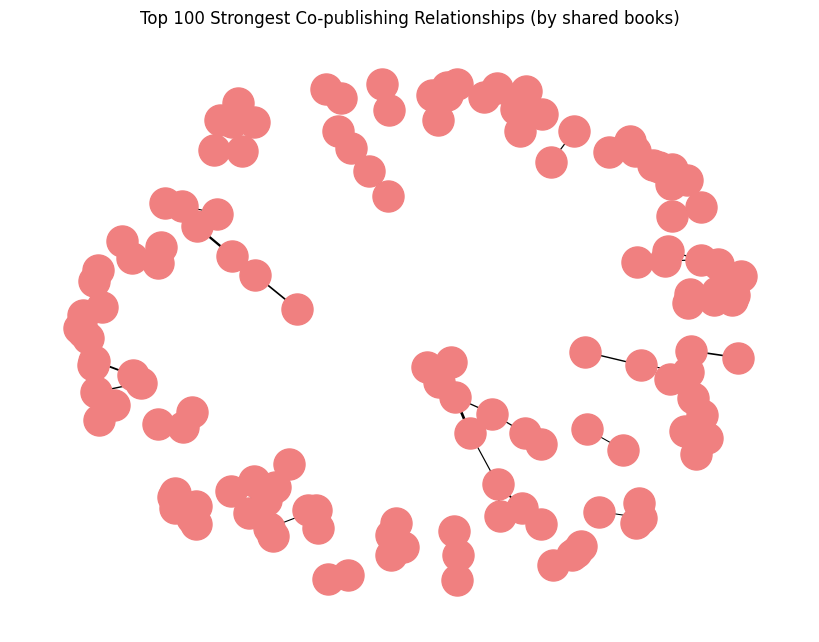

In [51]:
G_pub = create_network_from_edges(
    global_publisher_edges
)

plot_network(
    G_pub, 
    top_n=100,
    title='Top 100 Strongest Co-publishing Relationships (by shared books)',
    k=2.8,
    iterations=150,
    with_labels=False
)

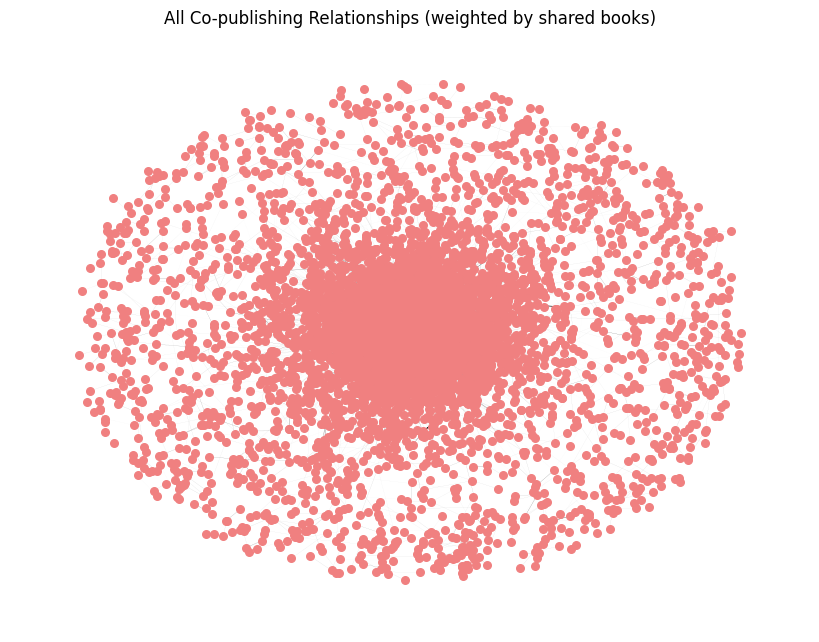

In [52]:
plot_network(
    G_pub, 
    k=0.8, iterations=50, node_size=30, with_labels=False, 
    title='All Co-publishing Relationships (weighted by shared books)'
)

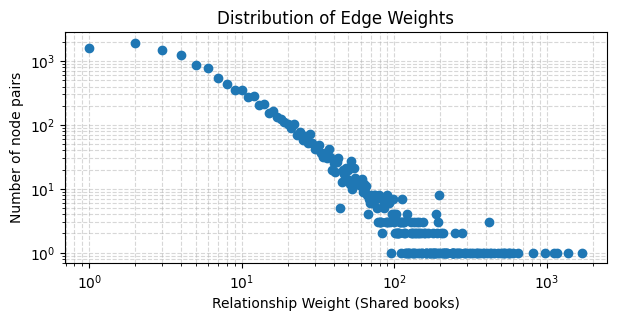

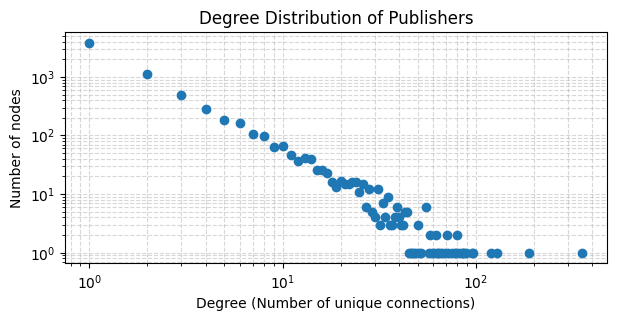

In [53]:
plot_edge_weight_distribution(global_publisher_edges, x_label='Relationship Weight (Shared books)')
plot_degree_distribution(G_pub, title='Degree Distribution of Publishers')

## Loose relationship
Connect only publishers that interacted with the same author.

Graph structure:
- Take the bipartite graph between authors and publishers, 
- then connect publishers based on the lowest weight of the two edges 
- sum the edges weight between publishers for every bipartite graph created for each author

In [54]:
pubs_filtered = f('all_publishers').filter(c('source') == current_source)

# Create base bipartite network (Author <-> Publisher) with edge weights 
author_pubs = (
    f('all_individual_actors')
    .filter(c('source') == current_source)
    .join(pubs_filtered, on=['record_number', 'source'], how='inner')
    .group_by('value', 'publisher')
    .agg(c('record_number').n_unique().alias('weight'))
)

# Join to find all publishers that interacted with the same author
df_all_loose_edges = p(
    author_pubs.rename({'publisher': 'publisher_1', 'weight': 'weight_1'})
    .join(
        author_pubs.rename({'publisher': 'publisher_2', 'weight': 'weight_2'}),
        on='value',
        how='inner'
    )
    .filter(c('publisher_1') < c('publisher_2'))
    .with_columns(
        loose_weight=nw.min_horizontal('weight_1', 'weight_2')
    )
).to_pandas()

df_all_loose_edges

,value,publisher_1,weight_1,publisher_2,weight_2,loose_weight
0,d$Thomas|a$Weinrichius|B$WidmungsempfängerIn|4...,Glück,1,Ligerus,1,1
1,9$004460022|V$Tpv1|7$gnd/121430006|w$piz|A$Meb...,Gössel,1,Vogt,1,1
2,9$004207459|V$Tpv1|7$gnd/115649042|w$piz|A$Ham...,"Typis & Sumptibus Josephi Dietrerici Hampelii,...",1,"Typis Josephus Dietericus Hampelii, Academiæ T...",1,1
3,9$006431097|V$Tpv1|7$gnd/124900208|w$piz|A$La ...,Unckel,2,Wessel,4,2
4,d$Johann David|a$Zang|B$BeiträgerIn|4$ctb,Michael,1,Reyher,1,1
...,...,...,...,...,...,...
3596370,9$008743738|V$Tpv1|7$gnd/118575449|w$piz|A$Lut...,Wilckius,2,Willius,2,2
3596371,9$008743738|V$Tpv1|7$gnd/118575449|w$piz|A$Lut...,Wilckius,2,[Schönermarck],2,2
3596372,9$008743738|V$Tpv1|7$gnd/118575449|w$piz|A$Lut...,Wilckius,2,[Humm,1,1
3596373,9$008743738|V$Tpv1|7$gnd/118575449|w$piz|A$Lut...,Wilckius,2,Zim[m]er,2,2


In [55]:
# Sum the loose weights between each publisher pair across all shared authors
global_loose_publisher_edges = (
    df_all_loose_edges
    .groupby(['publisher_1', 'publisher_2'])['loose_weight']
    .sum()
    .reset_index()
    .rename(columns={'loose_weight': 'weight'}) # Rename for helper functions
    .sort_values(by='weight', ascending=False)
)

total_loose_weight = global_loose_publisher_edges['weight'].sum()
total_loose_pairs = global_loose_publisher_edges.shape[0]

print(f"Total unique loose publisher pairs: {total_loose_pairs}")
print(f"Total sum of all loose relationship weights: {total_loose_weight}")

global_loose_publisher_edges.head(10)

Total unique loose publisher pairs: 1618330
Total sum of all loose relationship weights: 4492841


,publisher_1,publisher_2,weight
825467,Hake,Röhnerus,1920
1105977,Lanckisch,Ritzsch,1899
1440160,Schall,Typis Reyherianis,1785
1250200,Meyer,Meyerus,1689
826661,Hake,Wendt,1573
1423181,Röhnerus,Wendt,1559
728261,Gorman,Typis Cratonianis,1450
889127,Henckelius,Schrödterus,1370
477273,Endter,Endterus,1363
1513614,Steinmannus,Weidnerus,1339


In [56]:
G_pub_loose = create_network_from_edges(
    global_loose_publisher_edges
)

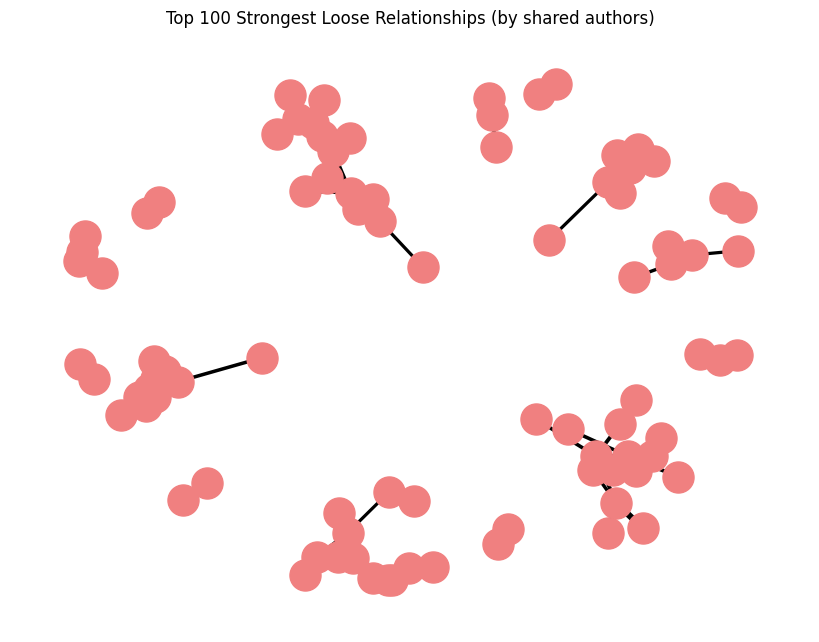

In [57]:
plot_network(
    G_pub_loose, 
    top_n=100,
    title='Top 100 Strongest Loose Relationships (by shared authors)',
    k=2.8,
    iterations=90,
    with_labels=False
)

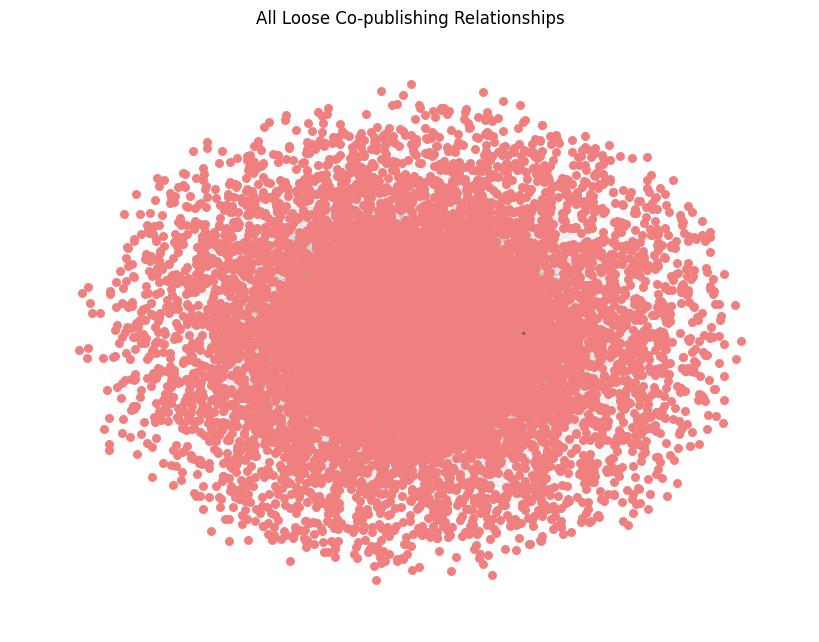

In [59]:
plot_network(
    G_pub_loose, 
    k=0.8, iterations=50, node_size=30, with_labels=False, 
    title='All Loose Co-publishing Relationships',
    # top_n=40000,
)

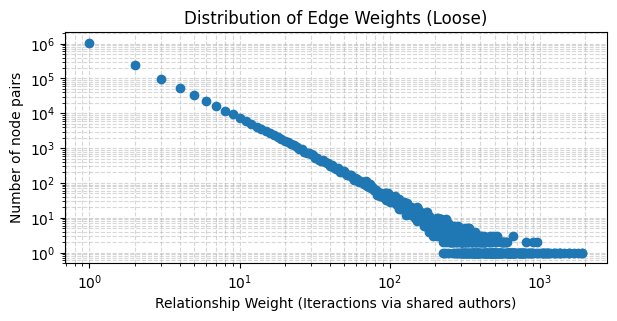

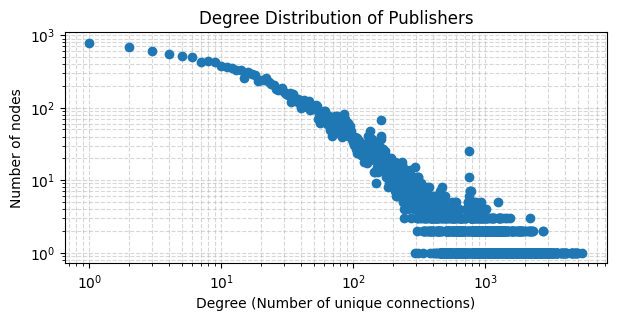

In [60]:
plot_edge_weight_distribution(
    global_loose_publisher_edges, 
    x_label='Relationship Weight (Iteractions via shared authors)',
    title='Distribution of Edge Weights (Loose)'
)
plot_degree_distribution(
    G_pub_loose, 
    title='Degree Distribution of Publishers'
)